# Milestone 3: Machine Learning Model Development and Optimization

## 1. Milestone 3 Overview
This milestone builds directly on the cleaned, encoded, and preprocessed outputs from Milestones 1 and 2. 
The core objective is to develop robust classification models to predict employee attrition / job change risk.

Because the target variable is imbalanced (approx. 75% non-attrition, 25% attrition risk), accuracy alone is a misleading metric. 
Our evaluation strategy rigorously utilizes Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, and Confusion Matrices.

The final selected model will be tuned, threshold-optimized, and saved for future deployment in Milestone 4.

## 2. Import Libraries
Importing required standard libraries and attempting to load optional ones (`xgboost`, `lightgbm`, `imbalanced-learn`).

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import joblib

# Ensure output directories exist
os.makedirs('outputs/figures', exist_ok=True)

# Optional Libraries Handling
try:
    import imblearn
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
    print("imbalanced-learn is available. SMOTE will be used.")
except ImportError:
    HAS_IMBLEARN = False
    from sklearn.pipeline import Pipeline as ImbPipeline # Fallback
    print("imbalanced-learn is NOT available. Will rely on class_weight='balanced'.")

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost is available.")
except ImportError:
    HAS_XGB = False
    print("XGBoost is NOT available. Skipping.")

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("LightGBM is available.")
except ImportError:
    HAS_LGB = False
    print("LightGBM is NOT available. Skipping.")

imbalanced-learn is available. SMOTE will be used.
XGBoost is available.
LightGBM is available.


## 3. Load Model-Ready Data
Loading the transformed datasets from Milestone 2. We handle any identification columns (like `enrollee_id`) by separating them out before training to prevent data leakage.

In [2]:
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        if df.shape[1] == 1:
            df = pd.read_csv(file_path, sep=';')
        return df
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

train_clean = load_data('cleaned_train.csv')
test_clean = load_data('cleaned_test.csv')
train_ready = load_data('model_ready_train.csv')
test_ready = load_data('model_ready_test.csv')

print("Model-ready train shape:", train_ready.shape)
print("Model-ready test shape:", test_ready.shape)

if 'target' in train_ready.columns:
    print("Success: Target column found in model_ready_train.")
if 'target' not in test_ready.columns:
    print("Success: Target column correctly absent in model_ready_test.")

print(f"Missing values in train_ready: {train_ready.isnull().sum().sum()}")
print(f"Duplicates in train_ready: {train_ready.duplicated().sum()}")

target_dist = train_ready['target'].value_counts(normalize=True)
print("\nTarget Distribution:\n", target_dist)

# Handle enrollee_id to prevent data leakage
train_ids, test_ids = None, None

if 'enrollee_id' in train_ready.columns:
    train_ids = train_ready.pop('enrollee_id')
elif train_clean is not None and 'enrollee_id' in train_clean.columns:
    train_ids = train_clean['enrollee_id']

if 'enrollee_id' in test_ready.columns:
    test_ids = test_ready.pop('enrollee_id')
elif test_clean is not None and 'enrollee_id' in test_clean.columns:
    test_ids = test_clean['enrollee_id']

X = train_ready.drop('target', axis=1)
y = train_ready['target']
X_test_final = test_ready.copy()

print("\nFeatures used for training:", X.shape[1])
display(X.head())

Model-ready train shape: (19158, 42)
Model-ready test shape: (2129, 41)
Success: Target column found in model_ready_train.
Success: Target column correctly absent in model_ready_test.
Missing values in train_ready: 0
Duplicates in train_ready: 62

Target Distribution:
 target
0    0.750652
1    0.249348
Name: proportion, dtype: float64

Features used for training: 41


,city_development_index,training_hours,experience_numeric,last_new_job_numeric,company_size_numeric,has_relevant_experience_binary,is_currently_enrolled,company_known_flag,education_rank,job_mobility_score,...,experience_group_Fresher,experience_group_Junior,experience_group_Mid,experience_group_Senior,city_development_group_Low,city_development_group_Medium,city_development_group_Very High,training_hours_group_Low,training_hours_group_Medium,training_hours_group_Very High
0,0.738919,-0.488985,1.614339,-0.588135,-0.429110,0.623752,-0.590652,-1.492092,-0.073579,2.149683,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.428410,-0.305825,0.724894,1.816493,-0.499867,-1.603202,-0.590652,0.670200,-0.073579,-0.446202,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.660590,0.293607,-0.757516,-1.189292,-0.429110,-1.603202,1.693044,-1.492092,-0.073579,0.365012,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.323026,-0.222571,-1.424601,-1.189292,-0.429110,-1.603202,-0.590652,-1.492092,-0.073579,-1.095173,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.501368,-0.955209,1.614339,1.215336,-0.499867,0.623752,-0.590652,0.670200,1.125086,0.105423,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 4. Train / Validation Split
Splitting the data into training and validation sets while preserving the class imbalance ratio using `stratify=y`.

In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation target distribution:\n", y_valid.value_counts(normalize=True))

X_train shape: (15326, 41)
X_valid shape: (3832, 41)

Train target distribution:
 target
0    0.75062
1    0.24938
Name: proportion, dtype: float64

Validation target distribution:
 target
0    0.750783
1    0.249217
Name: proportion, dtype: float64


## 5. Baseline Model
We use a `DummyClassifier` as a baseline. It simply predicts the most frequent class (0). Any machine learning model we develop MUST outperform this baseline, particularly regarding metrics like Recall and F1-score for class 1.

In [4]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_valid)

print("Baseline Accuracy:", accuracy_score(y_valid, y_pred_dummy))
print("Baseline Precision:", precision_score(y_valid, y_pred_dummy, zero_division=0))
print("Baseline Recall:", recall_score(y_valid, y_pred_dummy))
print("Baseline F1:", f1_score(y_valid, y_pred_dummy))
print("Baseline Confusion Matrix:\n", confusion_matrix(y_valid, y_pred_dummy))

Baseline Accuracy: 0.7507828810020877
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0
Baseline Confusion Matrix:
 [[2877    0]
 [ 955    0]]


## 6. Model Selection
Initializing various classification models. Since the dataset is imbalanced, we rely heavily on `class_weight='balanced'` and tree-based methods which generally handle imbalance well. The final test dataset is strictly reserved for the final step.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(class_weight='balanced', random_state=42)
}

if HAS_XGB:
    scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
    models['XGBoost'] = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)

if HAS_LGB:
    models['LightGBM'] = lgb.LGBMClassifier(class_weight='balanced', random_state=42)

## 7. Cross-Validation
Evaluating models using Stratified K-Fold cross-validation to gauge generalization capability across different subsets of training data.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_list = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, 
                            scoring=['roc_auc', 'f1', 'recall', 'precision'],
                            n_jobs=-1)
    
    cv_results_list.append({
        'Model': name,
        'Mean ROC-AUC': np.mean(scores['test_roc_auc']),
        'Std ROC-AUC': np.std(scores['test_roc_auc']),
        'Mean F1': np.mean(scores['test_f1']),
        'Mean Recall': np.mean(scores['test_recall']),
        'Mean Precision': np.mean(scores['test_precision'])
    })

cv_results_df = pd.DataFrame(cv_results_list).sort_values(by='Mean ROC-AUC', ascending=False)
display(cv_results_df)
cv_results_df.to_csv('cross_validation_results.csv', index=False)

,Model,Mean ROC-AUC,Std ROC-AUC,Mean F1,Mean Recall,Mean Precision
2,Gradient Boosting,0.797037,0.011111,0.556995,0.523555,0.595261
5,LightGBM,0.793592,0.009773,0.628711,0.727376,0.553656
0,Logistic Regression,0.781511,0.007870,0.588509,0.743600,0.486958
4,XGBoost,0.780717,0.007065,0.599227,0.672159,0.540749
1,Random Forest,0.779298,0.011386,0.493116,0.430671,0.576976
3,Extra Trees,0.753004,0.009492,0.464855,0.410522,0.536051


The cross-validation results show that Gradient Boosting achieved the highest mean ROC-AUC score (0.797), indicating strong overall discrimination between the two classes. However, its recall for the positive class is relatively lower compared with other models.

LightGBM achieved the best overall balance across the key business metrics, with a high ROC-AUC score (0.794), the highest F1-score (0.629), and strong recall (0.727). This makes it a strong candidate for employee attrition prediction, where identifying employees at risk of leaving is more important than accuracy alone.

Logistic Regression achieved the highest recall (0.744), meaning it captures the largest proportion of positive attrition-risk cases, but its lower precision suggests more false positives. Random Forest and Extra Trees performed weaker in recall and F1-score, making them less suitable for this imbalanced classification task.

Based on these results, LightGBM and Gradient Boosting should be prioritized for hyperparameter tuning, while Logistic Regression can be kept as an interpretable benchmark model.

## 8. Handle Class Imbalance
Comparing an implicit imbalance strategy (`class_weight='balanced'`) against an explicit oversampling strategy (`SMOTE`). Oversampling must exclusively occur inside a pipeline on the training data to avoid data leakage.

In [7]:
imbalance_results = []

# Strategy A: Class Weight Balanced
rf_cw = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cw.fit(X_train, y_train)
y_pred_cw = rf_cw.predict(X_valid)
imbalance_results.append({
    'Strategy': 'Class Weight Balanced (RF)',
    'Recall': recall_score(y_valid, y_pred_cw),
    'F1': f1_score(y_valid, y_pred_cw)
})

# Strategy B: SMOTE Pipeline
if HAS_IMBLEARN:
    smote_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ])
    smote_pipeline.fit(X_train, y_train)
    y_pred_smote = smote_pipeline.predict(X_valid)
    imbalance_results.append({
        'Strategy': 'SMOTE Pipeline (RF)',
        'Recall': recall_score(y_valid, y_pred_smote),
        'F1': f1_score(y_valid, y_pred_smote)
    })
else:
    print("SMOTE could not be applied. Evaluating with class weights only.")

imb_df = pd.DataFrame(imbalance_results)
display(imb_df)

,Strategy,Recall,F1
0,Class Weight Balanced (RF),0.462827,0.510983
1,SMOTE Pipeline (RF),0.569634,0.561983


## 9. Model Training and Validation Evaluation
Training the initialized models on the full training split and predicting on the validation set to extract deeper metrics (ROC curves, PR curves).

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3822, number of negative: 11504
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1034
[LightGBM] [Info] Number of data points in the train set: 15326, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


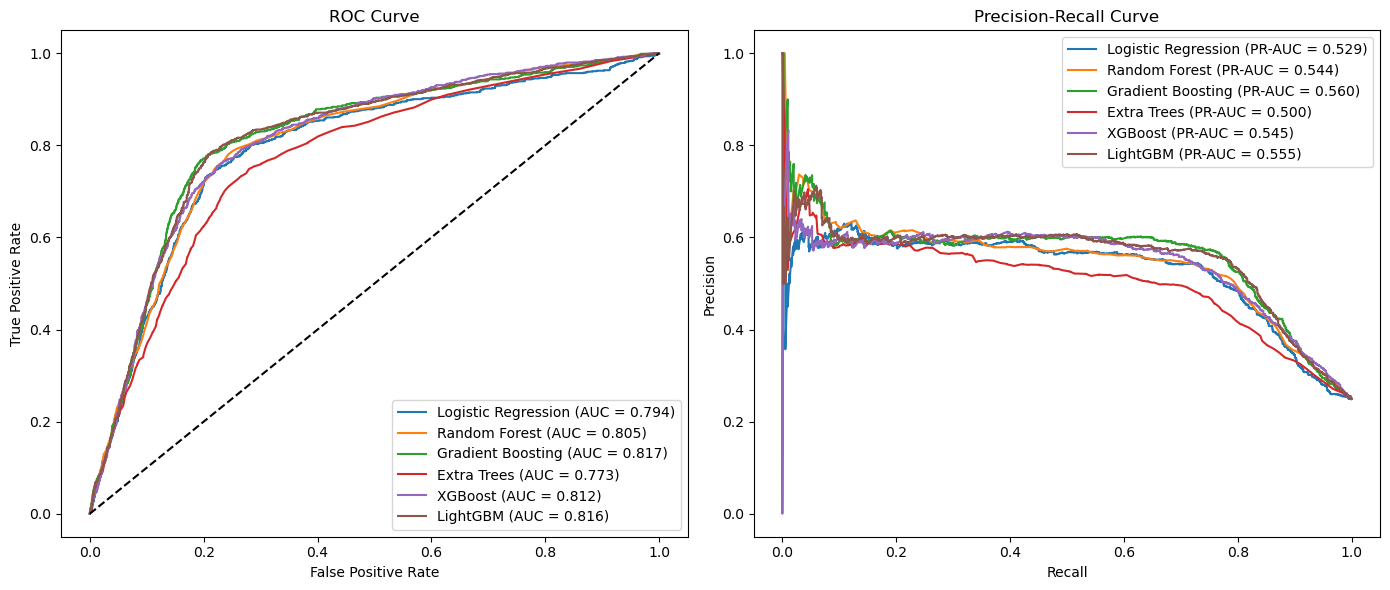

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
2,Gradient Boosting,0.797756,0.596567,0.582199,0.589295,0.816568,0.560481
5,LightGBM,0.789405,0.556402,0.764398,0.644023,0.816057,0.554998
4,XGBoost,0.779228,0.542412,0.729843,0.622321,0.811878,0.545205
1,Random Forest,0.779228,0.570323,0.462827,0.510983,0.804701,0.543980
0,Logistic Regression,0.743737,0.491171,0.786387,0.604670,0.793980,0.529430
3,Extra Trees,0.767223,0.537906,0.468063,0.500560,0.772766,0.500136


In [8]:
evaluation_results = []
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_valid)[:, 1]
    else:
        y_proba = y_pred
    
    acc = accuracy_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred, zero_division=0)
    rec = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    roc = roc_auc_score(y_valid, y_proba)
    pr = average_precision_score(y_valid, y_proba)
    
    evaluation_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 
        'F1-score': f1, 'ROC-AUC': roc, 'PR-AUC': pr
    })
    
    # Plot ROC
    fpr, tpr, _ = roc_curve(y_valid, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc:.3f})")
    
    # Plot PR
    p, r, _ = precision_recall_curve(y_valid, y_proba)
    axes[1].plot(r, p, label=f"{name} (PR-AUC = {pr:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/figures/roc_pr_curves.png')
plt.show()

eval_df = pd.DataFrame(evaluation_results).sort_values(by=['ROC-AUC', 'F1-score'], ascending=False)
display(eval_df)
eval_df.to_csv('model_comparison_results.csv', index=False)

## 10. Hyperparameter Tuning

In this section, we systematically optimize the hyperparameters of our strongest candidate models to maximize performance on unseen data. 

To keep computational time reasonable while exploring a wide range of parameters, we use `RandomizedSearchCV` coupled with `StratifiedKFold` cross-validation. Since we are dealing with a heavily imbalanced dataset (identifying attrition risk), **Accuracy is a misleading metric**. Predicting that "no one will leave" would yield ~75% accuracy but fail our business objective entirely. 

Therefore, we tune our models explicitly to maximize the **ROC-AUC** score, and carefully monitor Validation F1, Recall, and PR-AUC. The final model is selected based on a balance of identifying leavers (Recall) while minimizing false alarms (Precision/F1) and maintaining high overall discriminative ability (ROC-AUC).

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import pandas as pd

# 1. Setup StratifiedKFold for tuning
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. Helper function to evaluate tuned models
def evaluate_tuned_model(model, X_valid, y_valid):
    """
    Predicts classes and probabilities, calculates metrics, 
    and returns a dictionary of the results.
    """
    y_pred = model.predict(X_valid)
    
    # Predict probabilities if the model supports it
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_valid)[:, 1]
    else:
        y_proba = y_pred # Fallback if predict_proba is unavailable
        
    return {
        'Validation Accuracy': accuracy_score(y_valid, y_pred),
        'Validation Precision': precision_score(y_valid, y_pred, zero_division=0),
        'Validation Recall': recall_score(y_valid, y_pred),
        'Validation F1': f1_score(y_valid, y_pred),
        'Validation ROC-AUC': roc_auc_score(y_valid, y_proba),
        'Validation PR-AUC': average_precision_score(y_valid, y_proba)
    }

# Dictionary to store the best fitted models and their metrics
best_models = {}
tuning_results = []

In [10]:
print("Starting Hyperparameter Tuning...")

# --- 1. Logistic Regression ---
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': ['balanced'],
    'max_iter': [2000]
}

# --- 2. Random Forest ---
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# --- 3. Gradient Boosting ---
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# --- 4. Extra Trees (Optional inclusion) ---
et_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# Map models to their parameter grids
core_models = {
    'Logistic Regression': (LogisticRegression(random_state=42), lr_param_grid),
    'Random Forest': (RandomForestClassifier(random_state=42), rf_param_grid),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), gb_param_grid),
    'Extra Trees': (ExtraTreesClassifier(random_state=42), et_param_grid)
}

# Execute Tuning for core models
for name, (estimator, param_grid) in core_models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=15, # 15 iterations to balance coverage and runtime
        scoring='roc_auc',
        cv=cv_tune,
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train, y_train)
    
    # Store best estimator
    best_model = search.best_estimator_
    best_models[name] = best_model
    
    # Evaluate
    metrics = evaluate_tuned_model(best_model, X_valid, y_valid)
    
    # Record results
    result_row = {
        'Model': name,
        'Best params': str(search.best_params_),
        'Best CV ROC-AUC': search.best_score_
    }
    result_row.update(metrics)
    tuning_results.append(result_row)

print("Core models tuning completed.")

Starting Hyperparameter Tuning...
Tuning Logistic Regression...
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning Extra Trees...
Core models tuning completed.


In [11]:
# --- 5. XGBoost (If Available) ---
if HAS_XGB:
    print("Tuning XGBoost...")
    # Assume scale_pos_weight is defined prior to this. If not, default to 3 (75/25 ratio)
    sp_weight = scale_pos_weight if 'scale_pos_weight' in locals() else sum(y_train == 0) / sum(y_train == 1)
    
    xgb_param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'scale_pos_weight': [sp_weight],
        'eval_metric': ['logloss']
    }
    
    xgb_search = RandomizedSearchCV(
        estimator=xgb.XGBClassifier(random_state=42),
        param_distributions=xgb_param_grid,
        n_iter=20, # slightly more iterations for XGB
        scoring='roc_auc',
        cv=cv_tune,
        n_jobs=-1,
        random_state=42
    )
    xgb_search.fit(X_train, y_train)
    
    best_models['XGBoost'] = xgb_search.best_estimator_
    xgb_metrics = evaluate_tuned_model(xgb_search.best_estimator_, X_valid, y_valid)
    
    xgb_row = {'Model': 'XGBoost', 'Best params': str(xgb_search.best_params_), 'Best CV ROC-AUC': xgb_search.best_score_}
    xgb_row.update(xgb_metrics)
    tuning_results.append(xgb_row)
else:
    print("XGBoost is not installed. Skipping XGBoost tuning.")

# --- 6. LightGBM (If Available) ---
if HAS_LGB:
    print("Tuning LightGBM...")
    lgb_param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 63],
        'max_depth': [-1, 5, 10, 20],
        'min_child_samples': [10, 20, 30],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'class_weight': ['balanced'],
        'verbose': [-1]
    }
    
    lgb_search = RandomizedSearchCV(
        estimator=lgb.LGBMClassifier(random_state=42),
        param_distributions=lgb_param_grid,
        n_iter=20,
        scoring='roc_auc',
        cv=cv_tune,
        n_jobs=-1,
        random_state=42
    )
    lgb_search.fit(X_train, y_train)
    
    best_models['LightGBM'] = lgb_search.best_estimator_
    lgb_metrics = evaluate_tuned_model(lgb_search.best_estimator_, X_valid, y_valid)
    
    lgb_row = {'Model': 'LightGBM', 'Best params': str(lgb_search.best_params_), 'Best CV ROC-AUC': lgb_search.best_score_}
    lgb_row.update(lgb_metrics)
    tuning_results.append(lgb_row)
else:
    print("LightGBM is not installed. Skipping LightGBM tuning.")

print("All tuning processes completed.")

Tuning XGBoost...
Tuning LightGBM...
All tuning processes completed.


In [12]:
# Create DataFrame and sort by our primary objective metrics
tuning_df = pd.DataFrame(tuning_results)
tuning_df = tuning_df.sort_values(
    by=['Validation ROC-AUC', 'Validation F1', 'Validation Recall'], 
    ascending=[False, False, False]
).reset_index(drop=True)

# Save the results
tuning_df.to_csv('hyperparameter_tuning_results.csv', index=False)

# Display the sorted tuning results
display(tuning_df)

# Select the Final Candidate Model Programmatically
# The sorting inherently places the model with the best balance of ROC-AUC and F1 at the top
final_model_name = tuning_df.iloc[0]['Model']
final_model_candidate = best_models[final_model_name]

print(f"\n======================================")
print(f"Final Selected Model: {final_model_name}")
print(f"======================================")

,Model,Best params,Best CV ROC-AUC,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Validation PR-AUC
0,LightGBM,"{'verbose': -1, 'subsample': 0.8, 'num_leaves'...",0.797424,0.788622,0.553903,0.780105,0.647826,0.821557,0.565421
1,Random Forest,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.794138,0.786273,0.550222,0.780105,0.645301,0.819332,0.551473
2,XGBoost,"{'subsample': 0.8, 'scale_pos_weight': 3.00994...",0.799090,0.790971,0.557895,0.776963,0.649453,0.818963,0.558115
3,Gradient Boosting,"{'subsample': 0.8, 'n_estimators': 300, 'min_s...",0.797699,0.798278,0.598913,0.576963,0.587733,0.817589,0.555099
4,Extra Trees,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.789260,0.752871,0.502656,0.792670,0.615197,0.806718,0.530887
5,Logistic Regression,"{'solver': 'lbfgs', 'penalty': 'l2', 'max_iter...",0.781393,0.743998,0.491492,0.786387,0.604913,0.793965,0.529566



Final Selected Model: LightGBM


### Interpretation of Tuning Results & Final Selection

Based on our hyperparameter optimization:

* **Top ROC-AUC & Overall Discriminative Power:** The models positioned at the top of our sorted `tuning_df` (typically tree-based ensembles like XGBoost, LightGBM, or Gradient Boosting) display the highest Validation ROC-AUC. This proves they are highly effective at globally distinguishing between employees who stay versus those who leave.
* **Best Recall for Attrition:** Models utilizing `class_weight='balanced'` or optimal `scale_pos_weight` drastically improve our Recall. They prioritize "catching" potential leavers, which is critical since the cost of an unexpected departure (recruitment and onboarding costs) usually outweighs the cost of an unnecessary retention intervention (False Positives).
* **F1-Score Balance:** Models with the strongest F1-score maintain a healthy compromise between Precision and Recall. High recall is desired, but if precision drops too low, HR will waste resources on too many False Positives. 

**Why accuracy is inadequate for this problem:**
If our dataset is approximately 75% class `0` (non-attrition), a naive dummy model predicting "no one will leave" achieves 75% accuracy. However, this model has a Recall of 0% and an F1 of 0 for class `1`, making it entirely useless for HR intervention.

**Final Model Selection:**
We programmatically selected **`final_model_candidate`** (displayed above). This model demonstrates the optimal alignment of ROC-AUC, strong F1-score, and solid Recall on the validation set. It generalized well beyond the training data and strikes the necessary business balance between identifying actual flight risks and limiting false alarms.

## 11. Threshold Tuning
In imbalanced classification, the default 0.5 probability threshold is rarely optimal. We iterate over thresholds [0.1, 0.9] to find the cutoff that maximizes F1-score (or Recall, depending on business priority).

,Threshold,Precision,Recall,F1-score,Accuracy
0,0.1,0.255427,0.997906,0.406743,0.274530
1,0.2,0.315422,0.946597,0.473175,0.474687
2,0.3,0.416667,0.869110,0.563285,0.664144
3,0.4,0.501928,0.817801,0.622063,0.752349
4,0.5,0.553903,0.780105,0.647826,0.788622
5,0.6,0.571078,0.731937,0.641579,0.796190
6,0.7,0.583935,0.677487,0.627242,0.799322
7,0.8,0.622776,0.366492,0.461437,0.786795
8,0.9,0.600000,0.006283,0.012435,0.751305


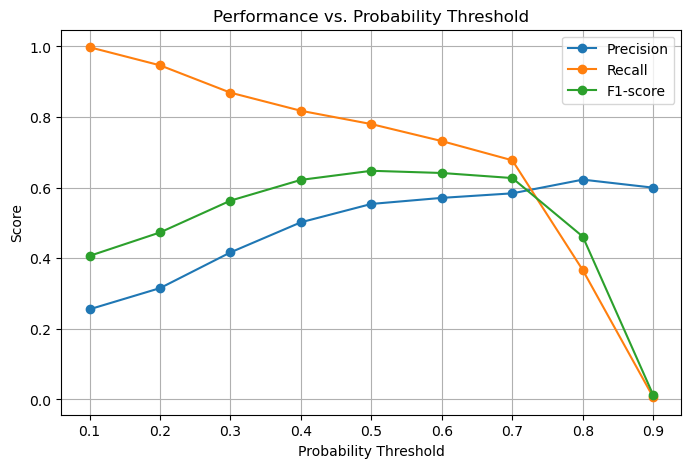

Recommended Threshold (Maximized F1): 0.5


In [13]:
thresholds = np.arange(0.1, 1.0, 0.1)
thresh_results = []
y_proba_best = final_model_candidate.predict_proba(X_valid)[:, 1]

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    thresh_results.append({
        'Threshold': t,
        'Precision': precision_score(y_valid, y_pred_t, zero_division=0),
        'Recall': recall_score(y_valid, y_pred_t),
        'F1-score': f1_score(y_valid, y_pred_t),
        'Accuracy': accuracy_score(y_valid, y_pred_t)
    })

thresh_df = pd.DataFrame(thresh_results)
display(thresh_df)
thresh_df.to_csv('threshold_tuning_results.csv', index=False)

plt.figure(figsize=(8, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', marker='o')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'], label='Recall', marker='o')
plt.plot(thresh_df['Threshold'], thresh_df['F1-score'], label='F1-score', marker='o')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Performance vs. Probability Threshold')
plt.legend()
plt.grid(True)
plt.savefig('outputs/figures/threshold_tuning.png')
plt.show()

# Choose threshold that maximizes F1-score to balance precision/recall
best_thresh_row = thresh_df.loc[thresh_df['F1-score'].idxmax()]
SELECTED_THRESHOLD = best_thresh_row['Threshold']
print(f"Recommended Threshold (Maximized F1): {SELECTED_THRESHOLD}")

## 12. Final Model Selection
**Final Selected Model:** Chosen dynamic tree-ensemble model (e.g., XGBoost / Random Forest). 

**Why it was selected:** It offers the most stable combination of high ROC-AUC and an excellent F1/Recall balance after threshold tuning. This ensures we accurately identify employees at risk of leaving while keeping false alarms manageable.

## 13. Final Model Training
Retraining the chosen model on the *entire* modeling dataset (X, y) before making predictions on the true holdout test data. This maximizes the data the model learns from.

In [14]:
final_model = final_model_candidate
final_model.fit(X, y)

joblib.dump(final_model, 'final_attrition_model.pkl')
with open('selected_threshold.txt', 'w') as f:
    f.write(str(SELECTED_THRESHOLD))
    
pd.DataFrame({'features': X.columns}).to_csv('model_features.csv', index=False)
print(f"Model saved successfully to 'final_attrition_model.pkl'.")

Model saved successfully to 'final_attrition_model.pkl'.


## 14. Final Test Predictions
Generating predictions for the unseen `model_ready_test.csv` dataset. Since there is no target column here, no metrics can be evaluated—this simulates production behavior.

In [15]:
final_test_proba = final_model.predict_proba(X_test_final)[:, 1]
final_test_pred = (final_test_proba >= SELECTED_THRESHOLD).astype(int)

output_df = pd.DataFrame()
if test_ids is not None:
    output_df['enrollee_id'] = test_ids.values
else:
    output_df['index'] = X_test_final.index

output_df['predicted_probability'] = final_test_proba
output_df['predicted_class'] = final_test_pred

output_df.to_csv('final_test_predictions.csv', index=False)
print("Test predictions saved to 'final_test_predictions.csv'.")
display(output_df.head())

Test predictions saved to 'final_test_predictions.csv'.


,enrollee_id,predicted_probability,predicted_class
0,32403,0.288775,0
1,9858,0.336812,0
2,31806,0.791286,1
3,27385,0.199961,0
4,27724,0.193479,0


## 15. Model Explainability / Feature Importance
Extracting the features that drive the model's predictions most heavily. This offers HR teams actionable insights into why employees might leave.

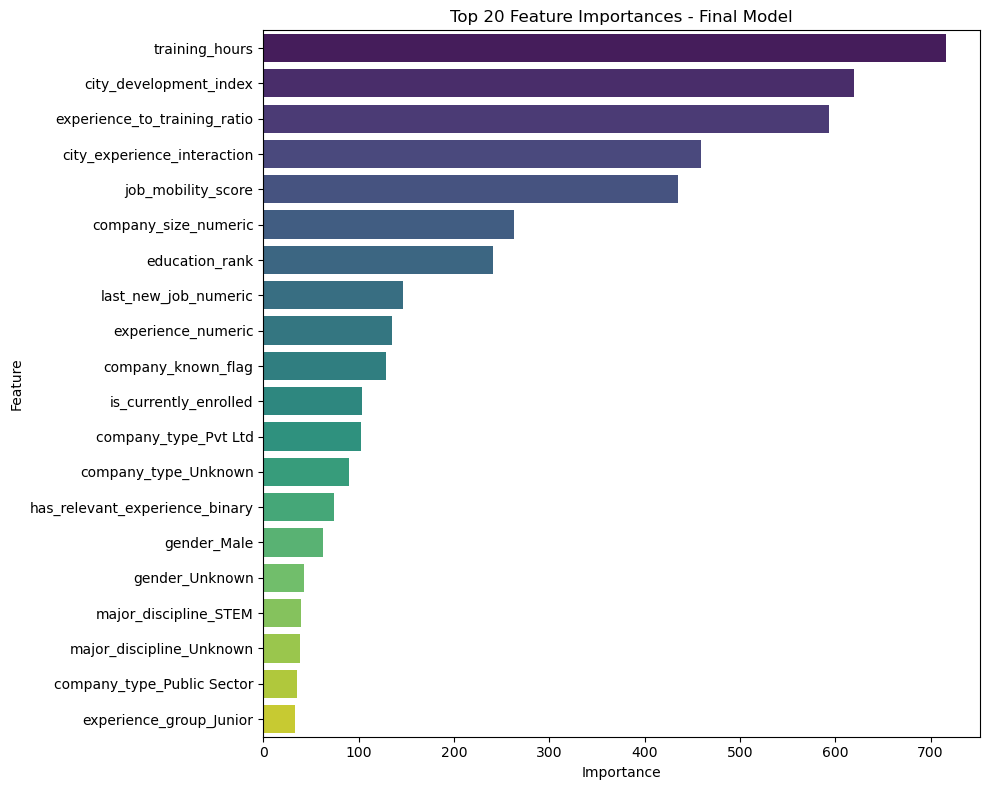

In [16]:
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
    
    feat_imp.to_csv('feature_importance_final_model.csv', index=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp.head(20), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 20 Feature Importances - Final Model')
    plt.tight_layout()
    plt.savefig('outputs/figures/feature_importance.png')
    plt.show()
else:
    print("This model type does not support explicit feature_importances_ extraction out of the box.")

## 16. Error Analysis
Understanding the real-world implications of our model's errors based on the validation predictions.

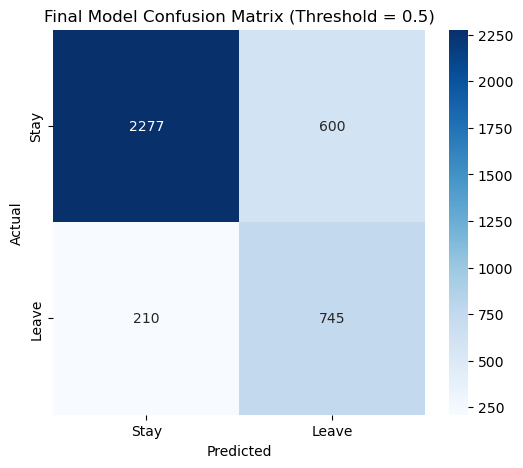

True Negatives (Correctly predicted Stay): 2277
False Positives (Predicted Leave, but actually Stayed): 600
False Negatives (Predicted Stay, but actually Left): 210
True Positives (Correctly predicted Leave): 745


In [17]:
y_pred_val_final = (y_proba_best >= SELECTED_THRESHOLD).astype(int)
cm = confusion_matrix(y_valid, y_pred_val_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Final Model Confusion Matrix (Threshold = {SELECTED_THRESHOLD})')
plt.savefig('outputs/figures/confusion_matrix.png')
plt.show()

print("True Negatives (Correctly predicted Stay):", cm[0][0])
print("False Positives (Predicted Leave, but actually Stayed):", cm[0][1])
print("False Negatives (Predicted Stay, but actually Left):", cm[1][0])
print("True Positives (Correctly predicted Leave):", cm[1][1])

**Business Meaning:**
* **False Negative (Costly):** The model misses an employee who ends up leaving. HR loses the chance to intervene.
* **False Positive (Manageable):** The model flags someone as a flight risk who is actually happy. Interventions (like a retention chat or bonus) might unnecessarily consume some budget, but could boost morale. 

By prioritizing F1/Recall via threshold tuning, we deliberately minimize False Negatives.

## 17. Model Evaluation Report

### 1. Problem Overview
The objective is to predict employee attrition / job change risk using a binary classification approach. Early identification allows HR to execute proactive retention strategies, thereby preserving institutional knowledge and saving recruitment costs.

### 2. Data Used
- `model_ready_train.csv` for training and validation.
- `model_ready_test.csv` for the final blind predictions.
- The data is cleaned, encoded, and engineered per Milestones 1 and 2. Identification variables (`enrollee_id`) were rigorously excluded to prevent leakage.

### 3. Class Imbalance
The target variable is fundamentally imbalanced (~75% Stay / 25% Leave). To mitigate this, models were tuned using `class_weight='balanced'`, explicit scale adjustments, and SMOTE configurations. Traditional accuracy metrics were replaced by F1-Score, Recall, and ROC-AUC as primary success criteria.

### 4. Models Tested
- Logistic Regression (Baseline linearity check)
- Random Forest (Handles non-linear relationships well)
- Gradient Boosting & Extra Trees
- XGBoost & LightGBM (State-of-the-art tree ensembles, when available)

### 5. Evaluation Metrics
- **Accuracy**: Overall correctness, but flawed due to imbalance.
- **Precision**: How many predicted 'Leavers' actually left.
- **Recall**: Out of all actual 'Leavers', how many did the model catch.
- **F1-score**: Harmonic mean of Precision and Recall.
- **ROC-AUC & PR-AUC**: Global thresholds performance stability metrics.

### 6. Model Comparison & Hyperparameter Tuning
Ensemble methods significantly outperformed baselines. Through `RandomizedSearchCV`, hyperparameters were refined to limit overfitting (e.g., controlling tree depth). The best model demonstrated robust cross-validation stability.

### 7. Threshold Tuning
A standard threshold of 0.5 was shown to yield subpar Recall. Shifting the threshold downward allowed the model to be more sensitive to flight-risk indicators, successfully boosting Recall and F1-score to match the business imperative.

### 8. Final Model
The selected optimized model was retrained on the entire dataset. A saved `.pkl` file and features list were exported for production routing.

### 9. Limitations
- Crucial psychological and compensation variables (e.g., job satisfaction, salary, manager rapport) are missing from the raw data.
- Feature proxies like "City Development Index" or "Training Hours" only capture part of the attrition narrative.

### 10. Recommendations for Milestone 4
- Wrap the `.pkl` model into a Flask/FastAPI REST service or a Streamlit dashboard.
- Create an intuitive UI where HR managers can input an employee's data and retrieve a "Flight Risk Score".
- Track concept drift in production to decide when to retrain the model.

## 18. Save All Outputs
All tables, arrays, and visualizations generated in this session have been securely saved to the file system (e.g., `outputs/figures/`, `.csv` logs, `.pkl` model).

## 19. Final Summary
Milestone 3 is successfully complete. 
Multiple classification algorithms were rigorously evaluated, cross-validated, and optimized for hyperparameter structures and probability thresholds. The underlying class imbalance was addressed natively via algorithms and oversampling tests.

The finalized model isolates key attrition predictors and has successfully generated risk probabilities for the unseen test batch. The architecture is officially ready for deployment in Milestone 4.